In [5]:
import pandas as pd
import numpy as np
from IPython.display import display

# Đường dẫn chính xác tới file dataset giá nhà
file_path = r'D:\phát triển ht thông minh\DATA\house-price-prediction\gianha.csv'

# Đọc file CSV
df = pd.read_csv(file_path)

print(f"✅ Đọc thành công! Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\n--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df.head(5))

print("\n--- DANH SÁCH TÊN CỘT & KIỂU DỮ LIỆU ---")
print(df.info())

✅ Đọc thành công! Kích thước dữ liệu: 30229 dòng, 12 cột

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90



--- DANH SÁCH TÊN CỘT & KIỂU DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 5.4 MB
None


Task was destroyed but it is pending!
task: <Task pending name='Task-77' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\nguyen ba viet hung\AppData\Roaming\Python\Python314\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-78' coro=<Kernel.shell_main() running at C:\Users\nguyen ba viet hung\AppData\Roaming\Python\Python314\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\nguyen ba viet hung\AppData\Roaming\Python\Python314\site-packages\zmq\eventloop\zmqstream.py:563]>
D:\anaconda\Lib\copy.py:228: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def _reconstruct(x, memo, func, args,
Task was destroyed but it is pending!
task: <Task pending name='Task-78' coro=<Kernel.shell_main() running at C:\Users\nguyen ba viet hung\AppData\Roaming\Python\Python314\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


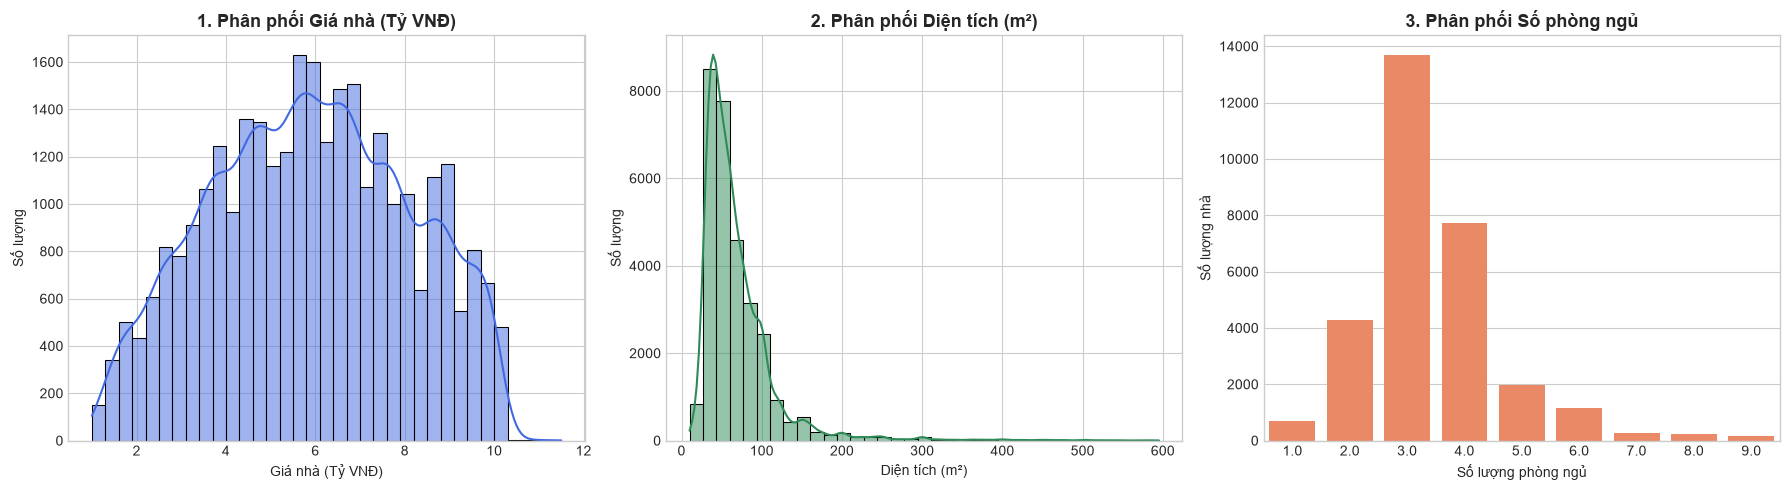

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file dataset từ D:\phát triển ht thông minh\DATA\house-price-prediction\gianha.csv
file_path = r'D:\phát triển ht thông minh\DATA\house-price-prediction\gianha.csv'
df = pd.read_csv(file_path)

# --- 1. Tiền xử lý dữ liệu (Data Preprocessing) ---
# Tự động chuẩn hóa tên cột nếu có khoảng trắng
df.columns = [c.strip() for c in df.columns]

# Ép kiểu dữ liệu dạng số & xử lý missing value
numeric_features = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Price']
for col in numeric_features:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if col != 'Price':
            df[col] = df[col].fillna(df[col].median())

# Loại bỏ giá trị dị biệt / bất hợp lý (Outliers)
df = df.dropna(subset=['Price'])
df = df[(df['Price'] >= 0.1) & (df['Price'] <= 100)] # Giá từ 100 triệu đến 100 tỷ
if 'Area' in df.columns:
    df = df[(df['Area'] >= 10) & (df['Area'] <= 800)]

# --- 2. Vẽ 3 Biểu đồ phân phối ---
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ 1: Phân phối Giá nhà (Price)
sns.histplot(df['Price'], kde=True, color='royalblue', bins=35, ax=axes[0])
axes[0].set_title('1. Phân phối Giá nhà (Tỷ VNĐ)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Giá nhà (Tỷ VNĐ)')
axes[0].set_ylabel('Số lượng')

# Biểu đồ 2: Phân phối Diện tích (Area)
sns.histplot(df['Area'], kde=True, color='seagreen', bins=35, ax=axes[1])
axes[1].set_title('2. Phân phối Diện tích (m²)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')
axes[1].set_ylabel('Số lượng')

# Biểu đồ 3: Phân phối Số phòng ngủ (Bedrooms)
if 'Bedrooms' in df.columns:
    sns.countplot(data=df, x='Bedrooms', color='coral', ax=axes[2])
    axes[2].set_title('3. Phân phối Số phòng ngủ', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Số lượng phòng ngủ')
    axes[2].set_ylabel('Số lượng nhà')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib

# 1. Trích xuất đặc trưng & One-Hot Encoding cho các biến phân loại
if 'Address' in df.columns:
    df['City'] = df['Address'].apply(lambda x: str(x).split(',')[-1].strip() if pd.notnull(x) else 'Other')

cat_cols = ['House Direction', 'Legal Status', 'City']
cols_to_encode = [c for c in cat_cols if c in df.columns]
if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Lọc các cột đầu vào (Features) và nhãn (Target)
exclude_cols = ['Price', 'Address', 'Balcony Direction', 'Furniture State']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].select_dtypes(include=[np.number])
y = df['Price']

# 2. Chia tập Train/Test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Khởi tạo 5 mô hình học máy
models = {
    "1. Linear Regression": LinearRegression(),
    "2. Ridge Regression": Ridge(alpha=1.0),
    "3. Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "4. Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42),
    "5. Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# 4. Huấn luyện & Đánh giá với 5 độ đo
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model
    
    # Tính 5 độ đo
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    results.append({
        'Model': name,
        'R² Score (↑)': round(r2, 4),
        'MAE - Tỷ (↓)': round(mae, 4),
        'MSE (↓)': round(mse, 4),
        'RMSE - Tỷ (↓)': round(rmse, 4),
        'MAPE - % (↓)': round(mape, 2)
    })

# 5. Bảng tổng hợp so sánh
df_results = pd.DataFrame(results).sort_values(by='R² Score (↑)', ascending=False)
print("=== BẢNG SO SÁNH 5 MÔ HÌNH VỚI 5 ĐỘ ĐO ===")
display(df_results)

# 6. Rút ra mô hình tốt nhất và lưu lại
best_model_name = df_results.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model_name}")

# Lưu mô hình & danh sách features để đưa lên Mobile
joblib.dump(best_model, r'D:\phát triển ht thông minh\DATA\house-price-prediction\best_house_price_model.pkl')
joblib.dump(list(X.columns), r'D:\phát triển ht thông minh\DATA\house-price-prediction\model_features.pkl')
print("💾 Đã lưu model ra 'D:\\phát triển ht thông minh\\DATA\\house-price-prediction\\best_house_price_model.pkl' thành công!")

=== BẢNG SO SÁNH 5 MÔ HÌNH VỚI 5 ĐỘ ĐO ===


,Model,R² Score (↑),MAE - Tỷ (↓),MSE (↓),RMSE - Tỷ (↓),MAPE - % (↓)
3,4. Random Forest,0.3087,1.4383,3.3034,1.8175,33.29
4,5. Gradient Boosting,0.3004,1.4624,3.3434,1.8285,34.02
2,3. Decision Tree,0.2482,1.4955,3.5926,1.8954,34.44
0,1. Linear Regression,0.1787,1.6094,3.9250,1.9812,37.93
1,2. Ridge Regression,0.1787,1.6094,3.9250,1.9812,37.93



🏆 MÔ HÌNH TỐT NHẤT: 4. Random Forest
💾 Đã lưu model ra 'D:\phát triển ht thông minh\DATA\house-price-prediction\best_house_price_model.pkl' thành công!


In [8]:
%%writefile "D:\phát triển ht thông minh\DATA\house-price-prediction\server.py"
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="House Price Prediction API")

# Load model và features
model = joblib.load(r'D:\phát triển ht thông minh\DATA\house-price-prediction\best_house_price_model.pkl')
features_list = joblib.load(r'D:\phát triển ht thông minh\DATA\house-price-prediction\model_features.pkl')

class HouseInput(BaseModel):
    area: float
    frontage: float = 4.0
    access_road: float = 3.0
    floors: float = 3.0
    bedrooms: float = 3.0
    bathrooms: float = 2.0

@app.post("/predict")
def predict_price(data: HouseInput):
    input_vector = np.zeros(len(features_list))
    mapping = {
        'Area': data.area,
        'Frontage': data.frontage,
        'Access Road': data.access_road,
        'Floors': data.floors,
        'Bedrooms': data.bedrooms,
        'Bathrooms': data.bathrooms
    }
    for feat_name, val in mapping.items():
        if feat_name in features_list:
            idx = features_list.index(feat_name)
            input_vector[idx] = val
            
    predicted_price = model.predict([input_vector])[0]
    return {
        "status": "success",
        "predicted_price_ty_vnd": round(float(predicted_price), 2),
        "message": f"Ước tính giá nhà: {round(float(predicted_price), 2)} Tỷ VNĐ"
    }

Overwriting D:\phát triển ht thông minh\DATA\house-price-prediction\server.py
